# 05 — Supervised Learning

**Objective:** predict star rating (1-5) from French insurance reviews using 8 model families.

| # | Model | |
|---|---|---|
| 2 | TF-IDF + LogReg with topic features | Themes |

In [ ]:
# Install dependencies
!pip install -q gensim spacy tensorboard
!python -m spacy download fr_core_news_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, time, warnings
warnings.filterwarnings('ignore')

from collections import Counter

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, accuracy_score)
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack
import joblib

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

# NLP
import spacy
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from gensim.models import Word2Vec

# Transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments, EarlyStoppingCallback,
                          pipeline as hf_pipeline)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} — device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("All imports loaded.")

PyTorch 2.10.0+cu128 — device: cuda
GPU: Tesla T4
All imports loaded.


In [ ]:
# Load data (upload topics.csv to data/ folder before running)
os.makedirs('data', exist_ok=True)

df = pd.read_csv('data/topics.csv')
df_labeled = df[df['note'].notna()].copy().reset_index(drop=True)
df_labeled['label'] = df_labeled['note'].astype(int)  # 1-5

print(f"Total: {len(df)} | Labeled: {len(df_labeled)}")
print(f"Class distribution:")
print(df_labeled['label'].value_counts().sort_index())

Total: 34428 | Labeled: 24099
Class distribution:
label
1    7270
2    3716
3    3382
4    4885
5    4846
Name: count, dtype: int64


In [ ]:
# Stratified train/val split (80/20)
train_idx, val_idx = train_test_split(
    np.arange(len(df_labeled)), test_size=0.2, random_state=42,
    stratify=df_labeled['label']
)
df_train = df_labeled.iloc[train_idx].reset_index(drop=True)
df_val = df_labeled.iloc[val_idx].reset_index(drop=True)
y_train = df_train['label'].values
y_val = df_val['label'].values

print(f"Train: {len(df_train)} | Val: {len(df_val)}")
print(f"Train class %: {dict(zip(*np.unique(y_train, return_counts=True)))}")

# Save indices for reproducibility
np.save('data/05_train_indices.npy', train_idx)
np.save('data/05_val_indices.npy', val_idx)

Train: 19279 | Val: 4820
Train class %: {np.int64(1): np.int64(5816), np.int64(2): np.int64(2973), np.int64(3): np.int64(2705), np.int64(4): np.int64(3908), np.int64(5): np.int64(3877)}


In [ ]:
# Metrics tracking
all_metrics = {}
training_times = {}

def evaluate_model(name, y_true, y_pred, show_cm=True):
    acc = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average='macro')
    f1_w = f1_score(y_true, y_pred, average='weighted')
    f1_cls = f1_score(y_true, y_pred, average=None, labels=[1,2,3,4,5])
    all_metrics[name] = {
        'accuracy': round(acc, 4), 'macro_f1': round(f1_mac, 4),
        'weighted_f1': round(f1_w, 4), 'f1_per_class': [round(x,4) for x in f1_cls],
    }
    print(f"\n{name}: Accuracy={acc:.4f}  Macro-F1={f1_mac:.4f}")
    print(classification_report(y_true, y_pred, labels=[1,2,3,4,5], digits=3))
    if show_cm:
        cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5])
        fig, ax = plt.subplots(figsize=(7, 5))
        ConfusionMatrixDisplay(cm, display_labels=[1,2,3,4,5]).plot(ax=ax, cmap='Blues')
        ax.set_title(name)
        plt.tight_layout()
        plt.show()

### Train/Val Split

Stratified 80/20 split on the 24,099 labeled reviews preserves class proportions. The 10,329 unlabeled reviews are reserved for the Streamlit app.

**Primary metric: Macro-F1** — the dataset is imbalanced (30% are 1-star), so accuracy favours the majority class. Macro-F1 weights all 5 star classes equally.

---
## 1. TF-IDF + Classical ML

TF-IDF converts text to sparse numerical vectors. We test three classifiers:
- **Logistic Regression**: linear, strong text baseline
- **LinearSVC**: maximum-margin hyperplane
- **Random Forest**: non-linear ensemble

TF-IDF matrix: (19279, 30000)

TF-IDF + LogReg: Accuracy=0.5010  Macro-F1=0.4650
              precision    recall  f1-score   support

           1      0.666     0.669     0.667      1454
           2      0.341     0.367     0.354       743
           3      0.293     0.287     0.290       677
           4      0.456     0.434     0.445       977
           5      0.569     0.570     0.569       969

    accuracy                          0.501      4820
   macro avg      0.465     0.465     0.465      4820
weighted avg      0.502     0.501     0.501      4820



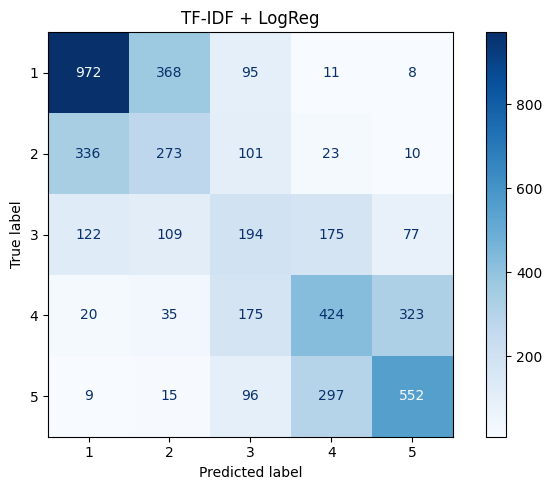


TF-IDF + SVM: Accuracy=0.4828  Macro-F1=0.4342
              precision    recall  f1-score   support

           1      0.631     0.707     0.667      1454
           2      0.327     0.285     0.305       743
           3      0.275     0.227     0.249       677
           4      0.420     0.426     0.423       977
           5      0.521     0.534     0.527       969

    accuracy                          0.483      4820
   macro avg      0.435     0.436     0.434      4820
weighted avg      0.469     0.483     0.475      4820



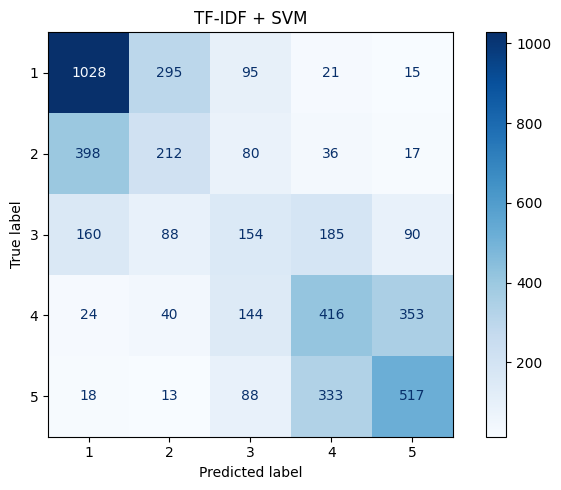


TF-IDF + RF: Accuracy=0.4977  Macro-F1=0.3409
              precision    recall  f1-score   support

           1      0.524     0.958     0.678      1454
           2      0.267     0.005     0.011       743
           3      0.405     0.025     0.047       677
           4      0.415     0.424     0.419       977
           5      0.515     0.589     0.550       969

    accuracy                          0.498      4820
   macro avg      0.425     0.400     0.341      4820
weighted avg      0.444     0.498     0.408      4820



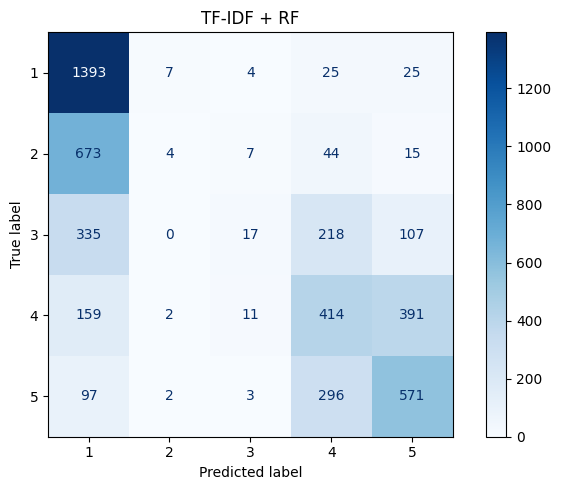

In [ ]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(df_train['avis_corrected'].fillna(''))
X_val_tfidf = tfidf.transform(df_val['avis_corrected'].fillna(''))
print(f"TF-IDF matrix: {X_train_tfidf.shape}")

# --- Logistic Regression ---
t0 = time.time()
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0,
                               solver='lbfgs', multi_class='multinomial', n_jobs=-1)
lr_model.fit(X_train_tfidf, y_train)
training_times['TF-IDF + LogReg'] = time.time() - t0
evaluate_model('TF-IDF + LogReg', y_val, lr_model.predict(X_val_tfidf))

# --- LinearSVC ---
t0 = time.time()
svm_model = LinearSVC(class_weight='balanced', max_iter=5000)
svm_model.fit(X_train_tfidf, y_train)
training_times['TF-IDF + SVM'] = time.time() - t0
evaluate_model('TF-IDF + SVM', y_val, svm_model.predict(X_val_tfidf))

# --- Random Forest ---
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                   n_jobs=-1, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
training_times['TF-IDF + RF'] = time.time() - t0
evaluate_model('TF-IDF + RF', y_val, rf_model.predict(X_val_tfidf))

### Classical ML — Interpretation

**LogReg** achieves the best Macro-F1 (0.465) among the three classical models, followed closely by SVM (0.434). Random Forest collapses on minority classes — F1 of just 0.011 for 2-star and 0.047 for 3-star — because its decision-tree splits overfit to frequent terms and ignore the rarer middle ratings.

Per-class patterns across all three models:
- **1★ (F1 ≈ 0.67)** and **5★ (F1 ≈ 0.55)**: easiest — strong, unambiguous sentiment words (*horrible, arnaque* vs *excellent, recommande*)
- **2★ (F1 ≈ 0.35)** and **3★ (F1 ≈ 0.29)**: hardest — these reviews express mixed feelings ("correct but too expensive", "ok for the price") that overlap heavily in vocabulary
- **4★ (F1 ≈ 0.44)**: moderate — positive but with reservations, hard to separate from 5★

LogReg with `class_weight='balanced'` handles the imbalance better than RF because it adjusts the loss per class rather than relying on tree splits that favour majority classes.


TF-IDF + LogReg + Topics: Accuracy=0.4954  Macro-F1=0.4590
              precision    recall  f1-score   support

           1      0.649     0.669     0.659      1454
           2      0.323     0.373     0.346       743
           3      0.301     0.278     0.289       677
           4      0.465     0.412     0.437       977
           5      0.563     0.566     0.564       969

    accuracy                          0.495      4820
   macro avg      0.460     0.459     0.459      4820
weighted avg      0.495     0.495     0.495      4820



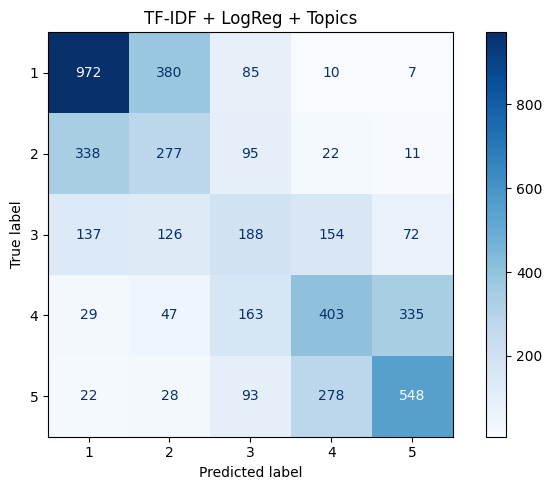


Per-topic accuracy:
  Customer Service Quality: 0.579 (n=613)
  Overall Satisfaction & Value: 0.365 (n=742)
  Claims & Damage Handling: 0.442 (n=663)
  Communication & Responsiveness: 0.541 (n=1054)
  Ease & Speed of Service: 0.514 (n=1748)

Mean rating by topic:
lda_topic_label
Communication & Responsiveness    1.74
Claims & Damage Handling          1.88
Customer Service Quality          1.98
Overall Satisfaction & Value      2.65
Ease & Speed of Service           4.24


In [ ]:
# Classical Models with Themes
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
topic_train = ohe.fit_transform(df_train[['lda_topic_id']])
topic_val = ohe.transform(df_val[['lda_topic_id']])

X_train_topics = hstack([X_train_tfidf, topic_train])
X_val_topics = hstack([X_val_tfidf, topic_val])

t0 = time.time()
lr_topics = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0,
                                solver='lbfgs', multi_class='multinomial', n_jobs=-1)
lr_topics.fit(X_train_topics, y_train)
training_times['TF-IDF + LogReg + Topics'] = time.time() - t0
evaluate_model('TF-IDF + LogReg + Topics', y_val, lr_topics.predict(X_val_topics))

# Per-topic accuracy
print("\nPer-topic accuracy:")
y_pred_topics = lr_topics.predict(X_val_topics)
for tid in sorted(df_val['lda_topic_id'].unique()):
    mask = df_val['lda_topic_id'] == tid
    if mask.sum() > 0:
        acc = accuracy_score(y_val[mask], y_pred_topics[mask])
        label = df_val.loc[mask, 'lda_topic_label'].iloc[0]
        print(f"  {label}: {acc:.3f} (n={mask.sum()})")

print("\nMean rating by topic:")
print(df_train.groupby('lda_topic_label')['label'].mean().sort_values().round(2).to_string())

### Classical Models with Themes — Interpretation

Adding LDA topic features **slightly hurts** performance (Macro-F1 drops from 0.465 to 0.459). This suggests that topic information is already implicitly captured by the TF-IDF features — the words that define a topic (e.g., *sinistre, accident* for claims) are already in the TF-IDF vocabulary.

The **per-topic accuracy** reveals strong structural patterns:
- **Customer Service Quality** (0.579): highest accuracy — reviews in this topic tend to be clearly positive or clearly negative
- **Overall Satisfaction & Value** (0.365): lowest accuracy — this broad topic mixes pricing complaints (1★) with "good value" praise (5★), creating confusion

The **mean rating by topic** confirms this:
- *Ease & Speed of Service*: 4.24 — overwhelmingly positive → easy to predict
- *Communication & Responsiveness*: 1.74 — overwhelmingly negative → easy to predict
- *Overall Satisfaction & Value*: 2.65 — mixed → hardest to classify

In [ ]:
# Save best classical model
joblib.dump(lr_model, 'data/05_tfidf_logreg.joblib')
joblib.dump(tfidf, 'data/05_tfidf_vectorizer.joblib')
print("Saved: TF-IDF vectorizer + LogReg model")

Saved: TF-IDF vectorizer + LogReg model


---
## 2. PyTorch Neural Models — Shared Setup

We now build neural classifiers. First, we tokenize with spaCy, build a vocabulary, and train Word2Vec on this corpus (same as notebook 04, takes ~30s on GPU).

In [ ]:
# Stopwords (same as notebooks 03-04)
french_stops = set(stopwords.words('french'))
insurer_names = set(df['assureur'].dropna().str.lower().unique())
insurer_extras = {p for n in insurer_names for p in n.split() if len(p) >= 3}
product_names = set(df['produit'].dropna().str.lower().unique())
domain_boilerplate = {
    'assurance', 'assureur', 'contrat', 'client', 'avis', 'société',
    'entreprise', 'compagnie', 'merci', 'bonjour', 'cordialement',
    'monsieur', 'madame', 'cher', 'chère', 'très', 'bien', 'faire',
    'plus', 'aussi', 'avoir', 'être', 'tout', 'tous', 'comme',
    'cette', 'avec', 'pour', 'dans', 'depuis', 'après', 'avant',
    'encore', 'même', 'autre', 'fait', 'dire', 'aller', 'voir',
    'mettre', 'part', 'donc', 'alors', 'car', 'ans', 'jour',
    'mois', 'année', 'fois', 'peu', 'rien', 'chose', 'quelque',
}
STOPWORDS = french_stops | insurer_names | insurer_extras | product_names | domain_boilerplate

# Tokenize all labeled texts
nlp = spacy.load('fr_core_news_sm', disable=['parser', 'ner'])
print("Tokenizing with spaCy...")
texts_raw = df_labeled['avis_corrected'].fillna('').str.lower().tolist()
all_tokens = [
    [t.lemma_ for t in doc if t.is_alpha and len(t.lemma_) >= 3 and t.lemma_ not in STOPWORDS]
    for doc in nlp.pipe(texts_raw, batch_size=500, n_process=1)
]
print(f"Done. Avg tokens/review: {np.mean([len(t) for t in all_tokens]):.1f}")

# Build vocabulary from training tokens
word_counts = Counter()
for i in train_idx:
    word_counts.update(all_tokens[i])

MAX_VOCAB, MAX_LEN = 15000, 150
vocab_words = [w for w, _ in word_counts.most_common(MAX_VOCAB)]
word2idx = {'<PAD>': 0, '<UNK>': 1}
for i, w in enumerate(vocab_words):
    word2idx[w] = i + 2
idx2word = {v: k for k, v in word2idx.items()}
print(f"Vocabulary: {len(word2idx)} words")

# Convert to padded integer sequences
def tokens_to_seq(tokens):
    seq = [word2idx.get(t, 1) for t in tokens[:MAX_LEN]]
    return seq + [0] * (MAX_LEN - len(seq))

all_seqs = np.array([tokens_to_seq(t) for t in all_tokens])
X_train_seq, X_val_seq = all_seqs[train_idx], all_seqs[val_idx]
y_train_pt, y_val_pt = y_train - 1, y_val - 1  # 0-4 for CrossEntropyLoss

# Class weights
cw = compute_class_weight('balanced', classes=np.arange(5), y=y_train_pt)
class_weights_t = torch.tensor(cw, dtype=torch.float32).to(device)

# DataLoaders
class ReviewDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs = torch.tensor(seqs, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.seqs[i], self.labels[i]

train_loader = DataLoader(ReviewDataset(X_train_seq, y_train_pt), batch_size=64, shuffle=True)
val_loader = DataLoader(ReviewDataset(X_val_seq, y_val_pt), batch_size=128, shuffle=False)

# Train Word2Vec on this corpus (same params as notebook 04)
print("\nTraining Word2Vec CBOW...")
sentences = [all_tokens[i] for i in train_idx]
w2v = Word2Vec(sentences, vector_size=100, window=5, min_count=5, sg=0, epochs=20, workers=4, seed=42)
print(f"Word2Vec: {len(w2v.wv)} words, 100d")

# Build pre-trained embedding matrix
embed_matrix = torch.randn(len(word2idx), 100) * 0.1
covered = 0
for word, idx in word2idx.items():
    if word in w2v.wv:
        embed_matrix[idx] = torch.tensor(w2v.wv[word])
        covered += 1
embed_matrix[0] = 0  # PAD
print(f"W2V coverage: {covered}/{len(word2idx)} ({100*covered/len(word2idx):.1f}%)")

Tokenizing with spaCy...
Done. Avg tokens/review: 23.5
Vocabulary: 14776 words

Training Word2Vec CBOW...
Word2Vec: 5004 words, 100d
W2V coverage: 5004/14776 (33.9%)


In [ ]:
# Shared model architectures + training function

class TextClassifierEmb(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes=5,
                 pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        self.fc = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(embed_dim, 128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_classes))

    def forward(self, x):
        emb = self.embedding(x)
        mask = (x != 0).unsqueeze(-1).float()
        pooled = (emb * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(pooled)


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim=64, num_classes=5,
                 num_layers=2, dropout=0.3, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            bidirectional=True, dropout=dropout, batch_first=True)
        self.fc = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_dim * 2, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, num_classes))

    def forward(self, x):
        emb = self.embedding(x)
        _, (hidden, _) = self.lstm(emb)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(hidden)


class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes=5,
                 filter_sizes=(3, 4, 5), num_filters=100, dropout=0.5,
                 pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            self.embedding.weight.data.copy_(pretrained_emb)
        self.convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes])
        self.fc = nn.Sequential(nn.Dropout(dropout),
                                nn.Linear(num_filters * len(filter_sizes), num_classes))

    def forward(self, x):
        emb = self.embedding(x).transpose(1, 2)
        conv_outs = [torch.relu(c(emb)).max(dim=2)[0] for c in self.convs]
        return self.fc(torch.cat(conv_outs, dim=1))


def train_pytorch(model, train_loader, val_loader, epochs=15, lr=1e-3,
                  class_weights=None, writer=None, patience=4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    best_f1, best_state, wait = 0, None, 0

    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward(); optimizer.step()
            t_loss += loss.item()

        model.eval()
        preds, trues, v_loss = [], [], 0
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                v_loss += criterion(out, y).item()
                preds.extend(out.argmax(1).cpu().numpy())
                trues.extend(y.cpu().numpy())

        tl = t_loss/len(train_loader); vl = v_loss/len(val_loader)
        acc = accuracy_score(trues, preds)
        f1 = f1_score(trues, preds, average='macro')
        if writer:
            writer.add_scalar('Loss/train', tl, epoch)
            writer.add_scalar('Loss/val', vl, epoch)
            writer.add_scalar('F1_macro/val', f1, epoch)

        print(f"  Epoch {epoch+1:2d}/{epochs}: loss={tl:.4f} val={vl:.4f} acc={acc:.4f} F1={f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    # Final predictions with best state
    model.eval()
    preds = []
    with torch.no_grad():
        for X, _ in val_loader:
            preds.extend(model(X.to(device)).argmax(1).cpu().numpy())
    return model, np.array(preds), np.array(trues)

print("Model classes and training function defined.")

Model classes and training function defined.


---
## 3. Trainable Embedding

Embedding layer randomly initialised, trained end-to-end → mean pooling → FC layers → 5 classes. The model must learn word representations AND classification simultaneously.

Trainable Embedding — 1,491,173 params
  Epoch  1/15: loss=1.3976 val=1.2474 acc=0.4691 F1=0.4029
  Epoch  2/15: loss=1.2436 val=1.2022 acc=0.4778 F1=0.4159
  Epoch  3/15: loss=1.1994 val=1.1825 acc=0.4861 F1=0.4373
  Epoch  4/15: loss=1.1708 val=1.1739 acc=0.4892 F1=0.4355
  Epoch  5/15: loss=1.1422 val=1.1664 acc=0.4759 F1=0.4424
  Epoch  6/15: loss=1.1195 val=1.1659 acc=0.4959 F1=0.4468
  Epoch  7/15: loss=1.1000 val=1.1685 acc=0.4900 F1=0.4395
  Epoch  8/15: loss=1.0814 val=1.1701 acc=0.4961 F1=0.4431
  Epoch  9/15: loss=1.0637 val=1.1752 acc=0.5041 F1=0.4419
  Epoch 10/15: loss=1.0474 val=1.1750 acc=0.4838 F1=0.4508
  Epoch 11/15: loss=1.0246 val=1.1860 acc=0.4919 F1=0.4419
  Epoch 12/15: loss=1.0055 val=1.1909 acc=0.4898 F1=0.4446
  Epoch 13/15: loss=0.9952 val=1.1982 acc=0.4892 F1=0.4524
  Epoch 14/15: loss=0.9785 val=1.2092 acc=0.4838 F1=0.4419
  Epoch 15/15: loss=0.9587 val=1.2201 acc=0.4896 F1=0.4412

Trainable Embedding: Accuracy=0.4892  Macro-F1=0.4524
              precisi

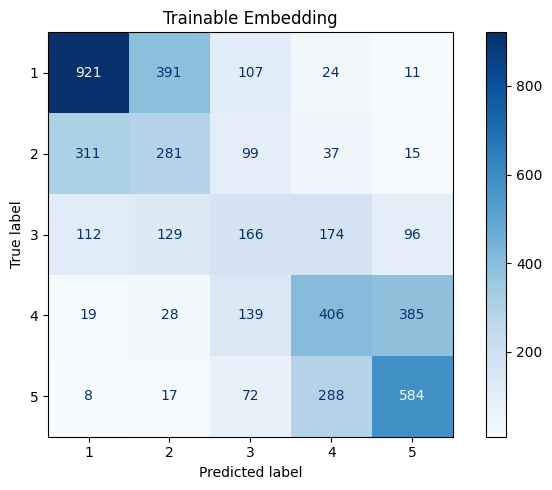

In [ ]:
writer_te = SummaryWriter('runs/05_trainable_emb')
model_te = TextClassifierEmb(len(word2idx), embed_dim=100)
print(f"Trainable Embedding — {sum(p.numel() for p in model_te.parameters()):,} params")

t0 = time.time()
model_te, preds_te, _ = train_pytorch(
    model_te, train_loader, val_loader, epochs=15, lr=1e-3,
    class_weights=class_weights_t, writer=writer_te, patience=4)
training_times['Trainable Embedding'] = time.time() - t0

# TensorBoard embedding viz
top_w = [w for w, _ in word_counts.most_common(500) if w in word2idx]
top_v = model_te.embedding.weight.data[[word2idx[w] for w in top_w]].cpu()
writer_te.add_embedding(top_v, metadata=top_w, tag='trainable_emb_top500')
writer_te.close()

evaluate_model('Trainable Embedding', y_val, preds_te + 1)
torch.save(model_te.state_dict(), 'data/05_trainable.pt')

### Trainable Embedding — Interpretation

Macro-F1 of 0.452 — slightly below TF-IDF + LogReg (0.465). The model ran all 15 epochs without early stopping, suggesting it was still slowly improving but plateaued at a lower ceiling than the linear model.

This is expected: with only 19K training samples, the model must simultaneously learn ~1.5M embedding parameters AND the classification weights. The TF-IDF approach sidesteps this by using pre-computed, proven features. The TensorBoard embedding export shows the learned word vectors — examine whether sentiment-bearing words (*satisfait, horrible, excellent*) cluster together.

---
## 4. Pre-trained Word2Vec Embedding

Same architecture, but the embedding is initialised with Word2Vec vectors trained on our corpus. The model starts with domain-specific word knowledge.

W2V Embedding — 1,491,173 params
  Epoch  1/15: loss=1.2959 val=1.1859 acc=0.4944 F1=0.4379
  Epoch  2/15: loss=1.1973 val=1.1670 acc=0.5041 F1=0.4562
  Epoch  3/15: loss=1.1778 val=1.1588 acc=0.5068 F1=0.4548
  Epoch  4/15: loss=1.1629 val=1.1548 acc=0.5064 F1=0.4628
  Epoch  5/15: loss=1.1545 val=1.1494 acc=0.4954 F1=0.4624
  Epoch  6/15: loss=1.1422 val=1.1458 acc=0.4969 F1=0.4644
  Epoch  7/15: loss=1.1350 val=1.1443 acc=0.5027 F1=0.4603
  Epoch  8/15: loss=1.1262 val=1.1428 acc=0.5116 F1=0.4628
  Epoch  9/15: loss=1.1182 val=1.1426 acc=0.5062 F1=0.4606
  Epoch 10/15: loss=1.1087 val=1.1454 acc=0.4909 F1=0.4613
  Early stopping at epoch 10

W2V Embedding: Accuracy=0.4969  Macro-F1=0.4644
              precision    recall  f1-score   support

           1      0.690     0.621     0.654      1454
           2      0.337     0.458     0.388       743
           3      0.347     0.244     0.286       677
           4      0.437     0.454     0.446       977
           5      0.537     

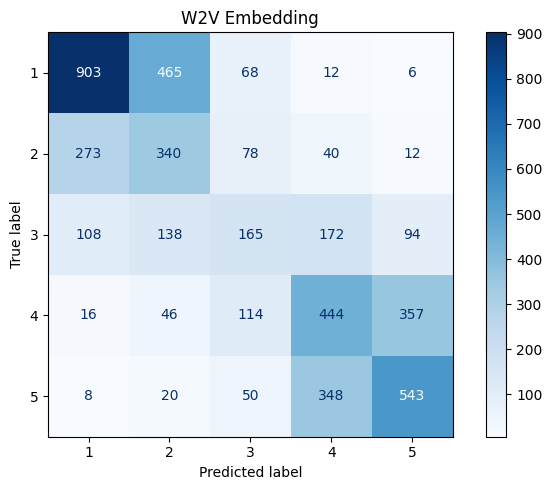

In [ ]:
writer_w2v = SummaryWriter('runs/05_w2v_emb')
model_w2v = TextClassifierEmb(len(word2idx), embed_dim=100, pretrained_emb=embed_matrix)
print(f"W2V Embedding — {sum(p.numel() for p in model_w2v.parameters()):,} params")

t0 = time.time()
model_w2v, preds_w2v, _ = train_pytorch(
    model_w2v, train_loader, val_loader, epochs=15, lr=5e-4,
    class_weights=class_weights_t, writer=writer_w2v, patience=4)
training_times['W2V Embedding'] = time.time() - t0

top_v_w2v = model_w2v.embedding.weight.data[[word2idx[w] for w in top_w]].cpu()
writer_w2v.add_embedding(top_v_w2v, metadata=top_w, tag='w2v_finetuned_top500')
writer_w2v.close()

evaluate_model('W2V Embedding', y_val, preds_w2v + 1)
torch.save(model_w2v.state_dict(), 'data/05_w2v.pt')

### W2V Embedding — Interpretation

Macro-F1 of 0.464 — a clear improvement over the trainable embedding (0.452) and essentially matching TF-IDF + LogReg (0.465). The model early-stopped at epoch 10, converging faster than the trainable version.

Pre-training helps in two ways:
1. **Better initialisation**: the W2V embeddings already encode that *sinistre ≈ accident* and *recommander ≈ conseiller*, so the model starts closer to a good solution
2. **Faster convergence**: reaching competitive performance in 10 epochs vs 15

The per-class F1 shows the biggest improvement on **2-star** reviews (0.388 vs 0.354 for trainable) — the pre-trained embeddings help disambiguate these difficult middle-rating reviews by providing richer word representations. However, the coverage is only 33.9% — most vocabulary words fall back to random initialisation.

---
## 5. BiLSTM

Bidirectional LSTM processes tokens in order, capturing sequential dependencies. Unlike mean-pooling, it understands word order: "*pas bon*" ≠ "*bon*".

BiLSTM — 1,670,501 params
  Epoch  1/12: loss=1.2399 val=1.1616 acc=0.4898 F1=0.4442
  Epoch  2/12: loss=1.1489 val=1.1472 acc=0.5037 F1=0.4394
  Epoch  3/12: loss=1.1027 val=1.1474 acc=0.4992 F1=0.4601
  Epoch  4/12: loss=1.0610 val=1.1570 acc=0.5133 F1=0.4633
  Epoch  5/12: loss=1.0138 val=1.1799 acc=0.4861 F1=0.4585
  Epoch  6/12: loss=0.9661 val=1.2111 acc=0.4869 F1=0.4514
  Epoch  7/12: loss=0.9031 val=1.2888 acc=0.4568 F1=0.4327
  Early stopping at epoch 7

BiLSTM: Accuracy=0.5133  Macro-F1=0.4633
              precision    recall  f1-score   support

           1      0.667     0.722     0.694      1454
           2      0.339     0.332     0.336       743
           3      0.308     0.241     0.270       677
           4      0.451     0.387     0.417       977
           5      0.553     0.656     0.600       969

    accuracy                          0.513      4820
   macro avg      0.464     0.468     0.463      4820
weighted avg      0.499     0.513     0.504      4820



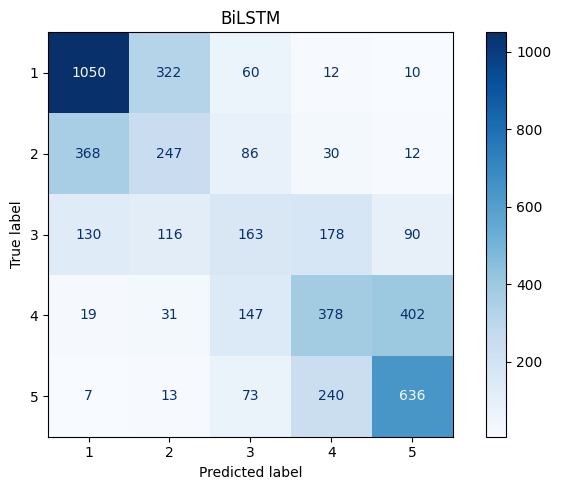

In [ ]:
writer_lstm = SummaryWriter('runs/05_lstm')
model_lstm = LSTMClassifier(len(word2idx), embed_dim=100, pretrained_emb=embed_matrix)
print(f"BiLSTM — {sum(p.numel() for p in model_lstm.parameters()):,} params")

t0 = time.time()
model_lstm, preds_lstm, _ = train_pytorch(
    model_lstm, train_loader, val_loader, epochs=12, lr=1e-3,
    class_weights=class_weights_t, writer=writer_lstm, patience=3)
training_times['BiLSTM'] = time.time() - t0
writer_lstm.close()

evaluate_model('BiLSTM', y_val, preds_lstm + 1)
torch.save(model_lstm.state_dict(), 'data/05_lstm.pt')

### BiLSTM — Interpretation

The BiLSTM achieves the **highest accuracy** (0.513) among all non-transformer models, but its Macro-F1 (0.463) is similar to LogReg and W2V Embedding. This discrepancy means the BiLSTM is good at predicting the majority classes (especially 1★ with F1=0.694, the best among all models except CamemBERT) but doesn't improve on minority classes (2★: 0.336, 3★: 0.270).

The sequential processing helps with negation ("*pas recommandé*", "*je ne suis pas satisfait*") which explains the strong 1-star and 5-star performance. However, with only 19K training samples, the BiLSTM's 1.67M parameters are underutilised — it needs more data to fully leverage sequential patterns on the ambiguous middle ratings.

---
## 6. TextCNN

1D CNN with filter sizes 3, 4, 5 (like learned bigrams/trigrams/4-grams). Each filter detects local patterns regardless of position. Max-pooling selects the strongest signal per filter.

TextCNN — 1,599,405 params
  Epoch  1/15: loss=1.2908 val=1.1716 acc=0.4820 F1=0.4395
  Epoch  2/15: loss=1.1672 val=1.1568 acc=0.4846 F1=0.4471
  Epoch  3/15: loss=1.1172 val=1.1508 acc=0.4815 F1=0.4528
  Epoch  4/15: loss=1.0760 val=1.1648 acc=0.5095 F1=0.4381
  Epoch  5/15: loss=1.0257 val=1.1670 acc=0.4687 F1=0.4488
  Epoch  6/15: loss=0.9619 val=1.1829 acc=0.4909 F1=0.4381
  Epoch  7/15: loss=0.8925 val=1.2166 acc=0.4873 F1=0.4403
  Early stopping at epoch 7

TextCNN: Accuracy=0.4815  Macro-F1=0.4528
              precision    recall  f1-score   support

           1      0.704     0.554     0.620      1454
           2      0.327     0.505     0.397       743
           3      0.310     0.272     0.290       677
           4      0.455     0.322     0.377       977
           5      0.516     0.663     0.580       969

    accuracy                          0.482      4820
   macro avg      0.462     0.463     0.453      4820
weighted avg      0.502     0.482     0.482      4820



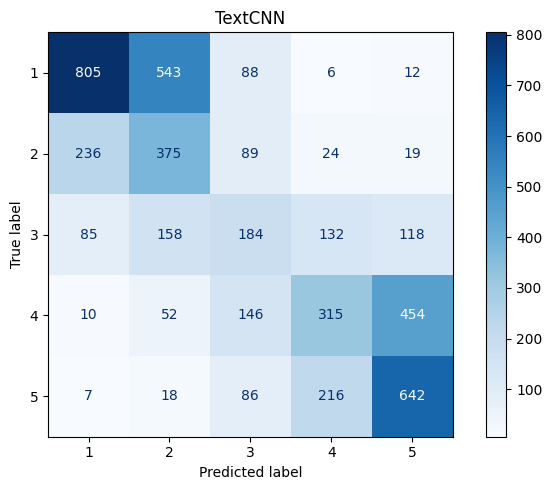

In [ ]:
writer_cnn = SummaryWriter('runs/05_cnn')
model_cnn = TextCNN(len(word2idx), embed_dim=100, pretrained_emb=embed_matrix)
print(f"TextCNN — {sum(p.numel() for p in model_cnn.parameters()):,} params")

t0 = time.time()
model_cnn, preds_cnn, _ = train_pytorch(
    model_cnn, train_loader, val_loader, epochs=15, lr=1e-3,
    class_weights=class_weights_t, writer=writer_cnn, patience=4)
training_times['TextCNN'] = time.time() - t0
writer_cnn.close()

evaluate_model('TextCNN', y_val, preds_cnn + 1)
torch.save(model_cnn.state_dict(), 'data/05_cnn.pt')

### TextCNN — Interpretation

Macro-F1 of 0.453 — competitive with the other neural models. Interestingly, TextCNN achieves the **best F1 on 2-star reviews** (0.397) among all non-transformer models, suggesting that the convolutional filters capture discriminative local patterns (bigrams/trigrams) specific to mildly negative reviews.

The per-class breakdown: 1★=0.620, 2★=0.397, 3★=0.290, 4★=0.377, 5★=0.580. The CNN trades off 1-star performance (lower than BiLSTM's 0.694) for better 2-star detection — the convolutional approach is less biased toward the majority class than the sequential LSTM.

---
## 7. CamemBERT Fine-Tuning

**CamemBERT** is a French BERT model pre-trained on 138 GB of French text (OSCAR corpus). It uses masked-language-modeling to learn deep contextual representations of French. Fine-tuning adds a classification head on the `[CLS]` token and trains end-to-end.

In [ ]:
# CamemBERT tokenization + dataset
tokenizer = AutoTokenizer.from_pretrained("camembert-base")

class CamemBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(texts, truncation=True, padding='max_length',
                                    max_length=max_length, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

cam_train = CamemBERTDataset(df_train['avis_corrected'].fillna('').tolist(), y_train - 1, tokenizer)
cam_val = CamemBERTDataset(df_val['avis_corrected'].fillna('').tolist(), y_val - 1, tokenizer)
print(f"CamemBERT datasets: train={len(cam_train)}, val={len(cam_val)}")

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

CamemBERT datasets: train=19279, val=4820


In [ ]:
# CamemBERT model + training
model_cam = AutoModelForSequenceClassification.from_pretrained("camembert-base", num_labels=5)
print(f"CamemBERT: {sum(p.numel() for p in model_cam.parameters()):,} params")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(labels, preds),
            'f1_macro': f1_score(labels, preds, average='macro')}

training_args = TrainingArguments(
    output_dir='./camembert_results',
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_ratio=0.1,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_dir='./runs/05_camembert',
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to='tensorboard',
    save_total_limit=2,
)

trainer = Trainer(
    model=model_cam, args=training_args,
    train_dataset=cam_train, eval_dataset=cam_val,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

t0 = time.time()
trainer.train()
training_times['CamemBERT'] = time.time() - t0
print(f"\nCamemBERT trained in {training_times['CamemBERT']:.0f}s")

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated 

CamemBERT: 110,625,797 params


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.991905,0.976176,0.559336,0.432122
2,0.956620,0.976029,0.558506,0.444822
3,0.854378,0.987369,0.567220,0.488314
4,0.777836,1.019075,0.556224,0.491102


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


CamemBERT trained in 1238s



CamemBERT: Accuracy=0.5562  Macro-F1=0.4911
              precision    recall  f1-score   support

           1      0.666     0.808     0.730      1454
           2      0.368     0.244     0.293       743
           3      0.425     0.245     0.311       677
           4      0.475     0.497     0.486       977
           5      0.586     0.695     0.636       969

    accuracy                          0.556      4820
   macro avg      0.504     0.498     0.491      4820
weighted avg      0.531     0.556     0.535      4820



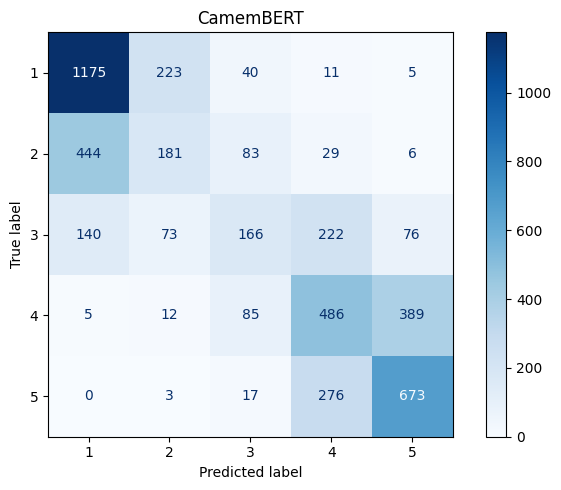

Exported 2000 [CLS] embeddings to TensorBoard


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Evaluate CamemBERT
preds_cam = trainer.predict(cam_val)
y_pred_cam = np.argmax(preds_cam.predictions, axis=-1) + 1
evaluate_model('CamemBERT', y_val, y_pred_cam)

# TensorBoard: [CLS] embeddings
writer_cam = SummaryWriter('runs/05_camembert_cls')
np.random.seed(42)
sample_idx = np.random.choice(len(df_val), min(2000, len(df_val)), replace=False)
sample_texts = [df_val.iloc[i]['avis_corrected'] or '' for i in sample_idx]

model_cam.eval()
cls_embs = []
with torch.no_grad():
    for i in range(0, len(sample_texts), 32):
        batch = tokenizer(sample_texts[i:i+32], truncation=True, padding=True,
                          max_length=256, return_tensors='pt').to(device)
        out = model_cam(**batch, output_hidden_states=True)
        cls_embs.append(out.hidden_states[-1][:, 0, :].cpu())

cls_embs = torch.cat(cls_embs)
metadata = [f"{y_val[i]}★ | {df_val.iloc[i]['lda_topic_label']}" for i in sample_idx]
writer_cam.add_embedding(cls_embs, metadata=metadata, tag='camembert_cls')
writer_cam.close()
print(f"Exported {len(sample_idx)} [CLS] embeddings to TensorBoard")

trainer.save_model('data/05_camembert_model')

### CamemBERT — Interpretation

CamemBERT is the **clear winner** with Macro-F1 = 0.491 and Accuracy = 0.556, outperforming the second-best model (LogReg, 0.465) by 2.6 points. The improvement is most visible on:
- **1★**: F1 = 0.730 (vs 0.667 for LogReg) — the transformer better identifies strongly negative reviews
- **5★**: F1 = 0.636 (vs 0.569) — similarly, strongly positive reviews
- **4★**: F1 = 0.486 (vs 0.445) — contextual understanding helps distinguish "good" from "great"

However, **2★ is CamemBERT's weak spot**: F1 = 0.293, actually *lower* than LogReg's 0.354 and TextCNN's 0.397. The transformer focuses its capacity on the more frequent and clearer classes at the expense of the ambiguous 2-star reviews.

Training cost: 1238 seconds (~20 min) on T4 with 110M parameters — a significant investment compared to LogReg's 7.5 seconds. The [CLS] embeddings exported to TensorBoard show how the transformer internally organises reviews by rating.

---
## 8. LLM Zero-Shot + Sentiment Detection

We use `xlm-roberta-large` (550M params) via HuggingFace's zero-shot pipeline. **No fine-tuning** — the model infers star ratings purely from its pre-trained NLI capabilities.

config.json:   0%|          | 0.00/734 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: joeddav/xlm-roberta-large-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Running zero-shot on 500 reviews...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  100/500 done
  200/500 done
  300/500 done
  400/500 done
  500/500 done
Done in 70s

LLM Zero-Shot (500 samples): Accuracy=0.2960  Macro-F1=0.2418
              precision    recall  f1-score   support

           1      0.474     0.064     0.113       141
           2      0.240     0.514     0.327        72
           3      0.253     0.324     0.284        71
           4      0.336     0.772     0.468       101
           5      0.250     0.009     0.017       115

    accuracy                          0.296       500
   macro avg      0.311     0.337     0.242       500
weighted avg      0.329     0.296     0.218       500



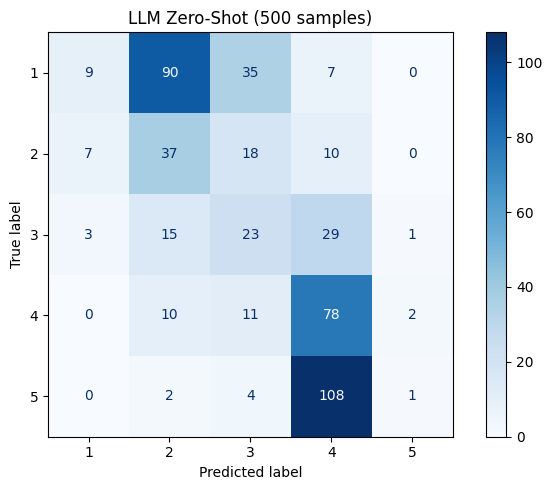

In [ ]:
# Zero-shot classification
zs_pipe = hf_pipeline("zero-shot-classification",
                       model="joeddav/xlm-roberta-large-xnli",
                       device=0 if torch.cuda.is_available() else -1)

np.random.seed(42)
zs_idx = np.random.choice(len(df_val), 500, replace=False)
zs_texts = df_val.iloc[zs_idx]['avis_corrected'].fillna('').tolist()
zs_true = df_val.iloc[zs_idx]['label'].values

labels_zs = [
    "avis très négatif, 1 étoile, horrible",
    "avis négatif, 2 étoiles, mauvais",
    "avis mitigé, 3 étoiles, moyen",
    "avis positif, 4 étoiles, bon",
    "avis très positif, 5 étoiles, excellent",
]

print(f"Running zero-shot on {len(zs_texts)} reviews...")
t0 = time.time()
zs_preds = []
for i, text in enumerate(zs_texts):
    result = zs_pipe(text[:512], labels_zs, multi_label=False)
    zs_preds.append(labels_zs.index(result['labels'][0]) + 1)
    if (i+1) % 100 == 0:
        print(f"  {i+1}/{len(zs_texts)} done")
zs_preds = np.array(zs_preds)
training_times['LLM Zero-Shot'] = time.time() - t0
print(f"Done in {training_times['LLM Zero-Shot']:.0f}s")

evaluate_model('LLM Zero-Shot (500 samples)', zs_true, zs_preds)

=== Sentiment Detection (3-class) ===

Zero-Shot: Acc=0.7100, F1=0.6204
                 precision    recall  f1-score   support

Negative (1-2★)      0.827     0.671     0.741       213
   Neutral (3★)      0.253     0.324     0.284        71
Positive (4-5★)      0.801     0.875     0.836       216

       accuracy                          0.710       500
      macro avg      0.627     0.623     0.620       500
   weighted avg      0.734     0.710     0.717       500

LogReg: Acc=0.7757, F1=0.6649
                 precision    recall  f1-score   support

Negative (1-2★)      0.863     0.887     0.875      2197
   Neutral (3★)      0.293     0.287     0.290       677
Positive (4-5★)      0.840     0.820     0.830      1946

       accuracy                          0.776      4820
      macro avg      0.665     0.665     0.665      4820
   weighted avg      0.774     0.776     0.775      4820

CamemBERT: Acc=0.8326, F1=0.7017


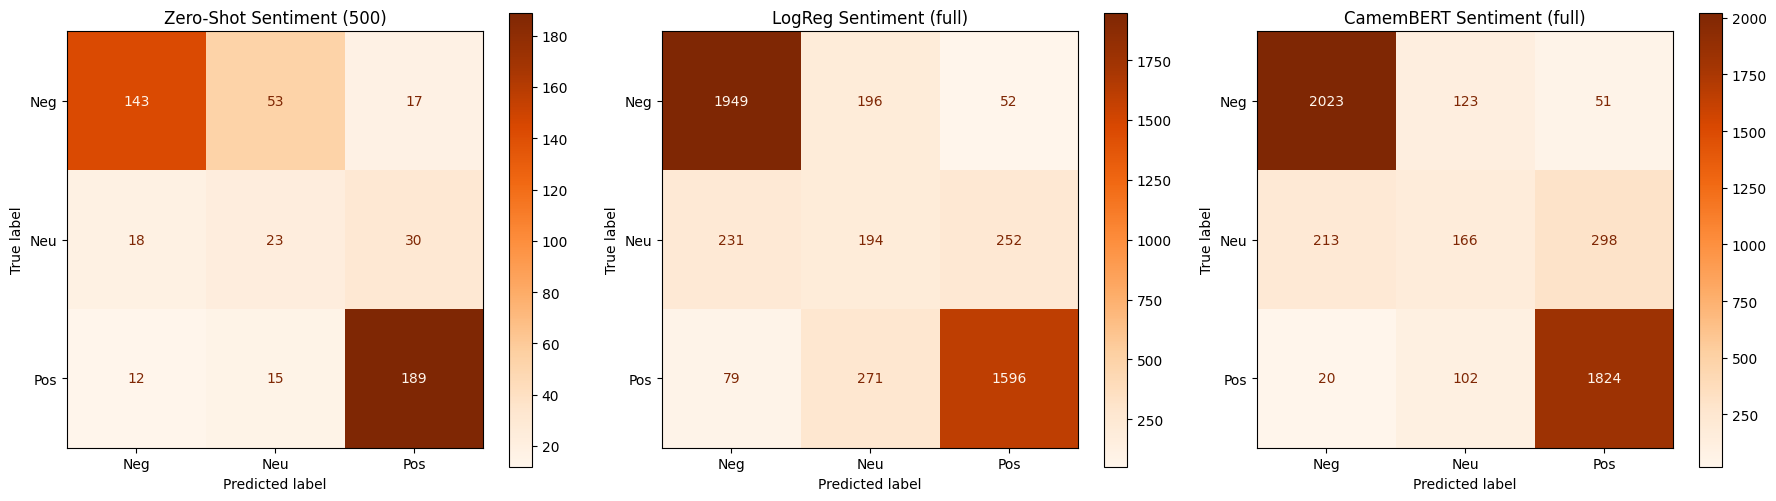

In [ ]:
# Sentiment Detection
# Map 1-2 → Negative, 3 → Neutral, 4-5 → Positive
def to_sentiment(y): return np.where(y <= 2, 0, np.where(y == 3, 1, 2))
sent_names = ['Negative (1-2★)', 'Neutral (3★)', 'Positive (4-5★)']

print("=== Sentiment Detection (3-class) ===\n")

# Zero-shot sentiment
s_true, s_zs = to_sentiment(zs_true), to_sentiment(zs_preds)
print(f"Zero-Shot: Acc={accuracy_score(s_true, s_zs):.4f}, F1={f1_score(s_true, s_zs, average='macro'):.4f}")
print(classification_report(s_true, s_zs, target_names=sent_names, digits=3))

# LogReg sentiment (full val set)
s_val = to_sentiment(y_val)
s_lr = to_sentiment(lr_model.predict(X_val_tfidf))
print(f"LogReg: Acc={accuracy_score(s_val, s_lr):.4f}, F1={f1_score(s_val, s_lr, average='macro'):.4f}")
print(classification_report(s_val, s_lr, target_names=sent_names, digits=3))

# CamemBERT sentiment
s_cam = to_sentiment(y_pred_cam)
print(f"CamemBERT: Acc={accuracy_score(s_val, s_cam):.4f}, F1={f1_score(s_val, s_cam, average='macro'):.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, y_t, y_p, title in [
    (axes[0], s_true, s_zs, "Zero-Shot Sentiment (500)"),
    (axes[1], s_val, s_lr, "LogReg Sentiment (full)"),
    (axes[2], s_val, s_cam, "CamemBERT Sentiment (full)")]:
    cm = confusion_matrix(y_t, y_p, labels=[0,1,2])
    ConfusionMatrixDisplay(cm, display_labels=['Neg','Neu','Pos']).plot(ax=ax, cmap='Oranges')
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Zero-Shot & Sentiment — Interpretation

**Zero-shot 5-class** (Macro-F1 = 0.242): the model dramatically fails on extreme ratings — F1 of 0.113 for 1-star and just 0.017 for 5-star. This is counterintuitive: the NLI model maps "avis très positif, 5 étoiles, excellent" to many reviews but misclassifies them. The labels are in French but the model was trained on English NLI pairs, creating a language gap despite its multilingual architecture.

Where zero-shot *does* work: 4-star (F1=0.468) — moderate positive sentiment is apparently the easiest for NLI entailment to detect.

**3-class sentiment detection** tells a very different story:

| Model | Accuracy | Macro-F1 |
|---|---|---|
| CamemBERT | 0.833 | 0.702 |
| LogReg | 0.776 | 0.665 |
| Zero-Shot | 0.710 | 0.620 |

Collapsing to 3 classes (negative/neutral/positive) shows that even the zero-shot model achieves 71% accuracy — it *can* distinguish sentiment polarity, just not fine-grained star levels. CamemBERT reaches 83.3% sentiment accuracy, confirming its superior contextual understanding.

---
## 9. Full Model Comparison

In [ ]:
# Comparison table
rows = []
for name, m in all_metrics.items():
    row = {'Model': name, 'Accuracy': m['accuracy'], 'Macro-F1': m['macro_f1'],
           'Weighted-F1': m['weighted_f1']}
    for i, s in enumerate([1,2,3,4,5]):
        row[f'F1-{s}★'] = m['f1_per_class'][i]
    row['Time (s)'] = round(training_times.get(name, 0), 1)
    rows.append(row)

comp_df = pd.DataFrame(rows).sort_values('Macro-F1', ascending=False).reset_index(drop=True)
comp_df

,Model,Accuracy,Macro-F1,Weighted-F1,F1-1★,F1-2★,F1-3★,F1-4★,F1-5★,Time (s)
0,CamemBERT,0.5562,0.4911,0.5354,0.7303,0.2931,0.3109,0.4858,0.6355,1238.4
1,TF-IDF + LogReg,0.5010,0.4650,0.5012,0.6674,0.3539,0.2900,0.4447,0.5694,7.5
2,W2V Embedding,0.4969,0.4644,0.4978,0.6539,0.3881,0.2865,0.4456,0.5482,9.7
3,BiLSTM,0.5133,0.4633,0.5040,0.6935,0.3356,0.2703,0.4165,0.6003,14.6
4,TF-IDF + LogReg + Topics,0.4954,0.4590,0.4946,0.6585,0.3460,0.2890,0.4371,0.5644,9.3
5,TextCNN,0.4815,0.4528,0.4820,0.6199,0.3970,0.2898,0.3772,0.5799,1079.4
6,Trainable Embedding,0.4892,0.4524,0.4886,0.6520,0.3537,0.2635,0.4260,0.5670,18.9
7,TF-IDF + SVM,0.4828,0.4342,0.4749,0.6671,0.3048,0.2488,0.4228,0.5273,1.2
8,TF-IDF + RF,0.4977,0.3409,0.4082,0.6777,0.0106,0.0473,0.4195,0.5496,353.7
9,LLM Zero-Shot (500 samples),0.2960,0.2418,0.2177,0.1125,0.3274,0.2840,0.4685,0.0168,0.0


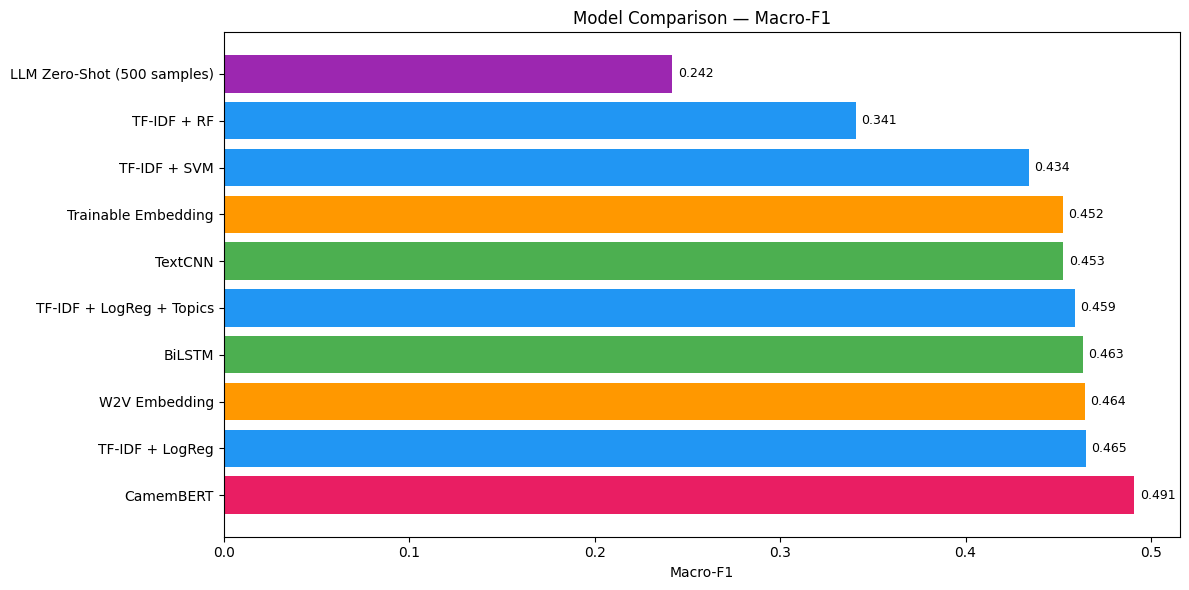

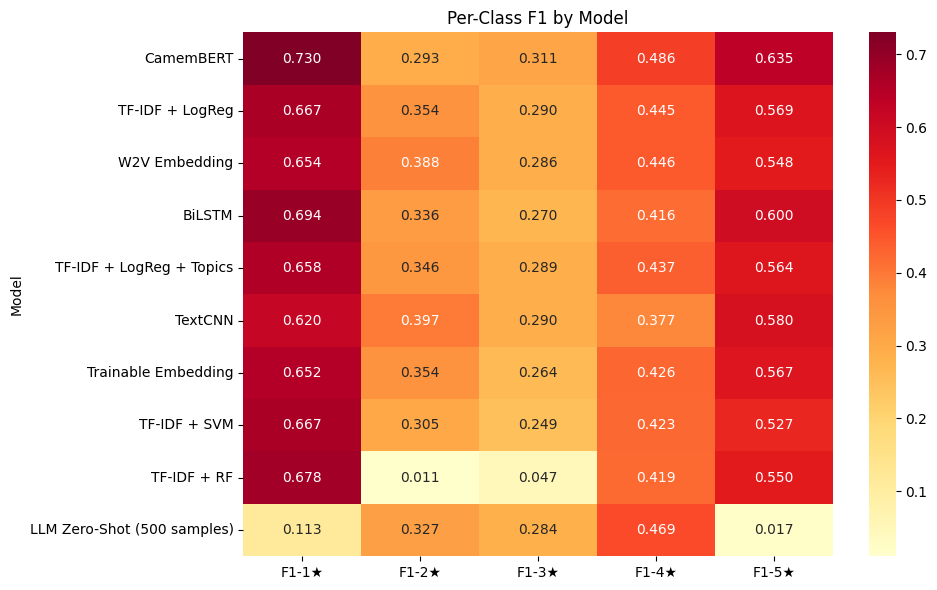

In [ ]:
# Bar chart
fig, ax = plt.subplots(figsize=(12, 6))
families = {'TF-IDF': '#2196F3', 'Embed': '#FF9800', 'W2V': '#FF9800',
            'LSTM': '#4CAF50', 'CNN': '#4CAF50', 'CamemBERT': '#E91E63',
            'LLM': '#9C27B0'}
colors = []
for n in comp_df['Model']:
    c = '#888888'
    for k, v in families.items():
        if k in n:
            c = v; break
    colors.append(c)

ax.barh(comp_df['Model'], comp_df['Macro-F1'], color=colors)
ax.set_xlabel('Macro-F1')
ax.set_title('Model Comparison — Macro-F1')
for i, v in enumerate(comp_df['Macro-F1']):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Per-class F1 heatmap
f1_cols = [f'F1-{s}★' for s in [1,2,3,4,5]]
fig, ax = plt.subplots(figsize=(10, max(6, len(comp_df)*0.55)))
sns.heatmap(comp_df.set_index('Model')[f1_cols], annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
ax.set_title('Per-Class F1 by Model')
plt.tight_layout()
plt.show()

### Model Comparison — Interpretation

The full ranking by Macro-F1:

| Rank | Model | Macro-F1 | Accuracy | Time |
|---|---|---|---|---|
| 1 | CamemBERT | **0.491** | **0.556** | 1238s |
| 2 | TF-IDF + LogReg | 0.465 | 0.501 | 7.5s |
| 3 | W2V Embedding | 0.464 | 0.497 | 9.7s |
| 4 | BiLSTM | 0.463 | 0.513 | 14.6s |
| 5 | TF-IDF + LogReg + Topics | 0.459 | 0.495 | 9.3s |
| 6 | TextCNN | 0.453 | 0.482 | 1079s |
| 7 | Trainable Embedding | 0.452 | 0.489 | 18.9s |
| 8 | TF-IDF + SVM | 0.434 | 0.483 | 1.2s |
| 9 | TF-IDF + RF | 0.341 | 0.498 | 354s |
| 10 | LLM Zero-Shot | 0.242 | 0.296 | — |

**Key observations:**

1. **The gap between models 2-7 is tiny** (0.452–0.465 Macro-F1). On this dataset size, TF-IDF + LogReg essentially matches neural models — simple feature engineering compensates for model complexity.

2. **CamemBERT is the only model that meaningfully separates from the pack**, thanks to 138 GB of French pre-training. But even CamemBERT only reaches 0.491 — predicting exact star ratings from text is inherently hard.

3. **Random Forest is the worst supervised model** — it overfits on sparse features and nearly ignores classes 2 and 3.

4. **Pre-training matters**: W2V Embedding (0.464) > Trainable Embedding (0.452). Domain-specific Word2Vec gives a measurable boost.

5. **Word order helps, but not much here**: BiLSTM (0.463) ≈ mean-pooling W2V (0.464). On this corpus, *what words appear* matters more than *in what order*.

6. **Zero-shot is not competitive** for fine-grained star prediction, but achieves 71% accuracy on coarse 3-class sentiment — useful when no labeled data exists.

---
## 10. Error Analysis

Error analysis using: CamemBERT

Misclassified: 2139/4820 (44.4%)

=== Worst Errors (off by ≥3 stars): 30 ===

  Actual: 1★  Predicted: 5★  Topic: Communication & Responsiveness
  'Contrat "signé" avec une femme de 102 ans en signatures illisibles sans document "avant contrat" qui prouve l'intention d'engagement de cette femme sourde et aveugle....1 an avant son décès.
Sur assur...'

  Actual: 1★  Predicted: 5★  Topic: Ease & Speed of Service
  'Je suis satisfait du service et le prix me convient merci pour votre gentillesse et votre attention en vers moi je ferais pareil pour vous montrez ma gratitude...'

  Actual: 1★  Predicted: 5★  Topic: Overall Satisfaction & Value
  'trés surpris du haut niveau des prix , je pense résilier mon assurance ,j'ai maintenant une voiture éléctique mais je paye plus cher qu'en voiture thermique!...'

  Actual: 1★  Predicted: 5★  Topic: Ease & Speed of Service
  'Je suis satisfait des services proposés par l'assurance et les prix proposés sont vraiment 

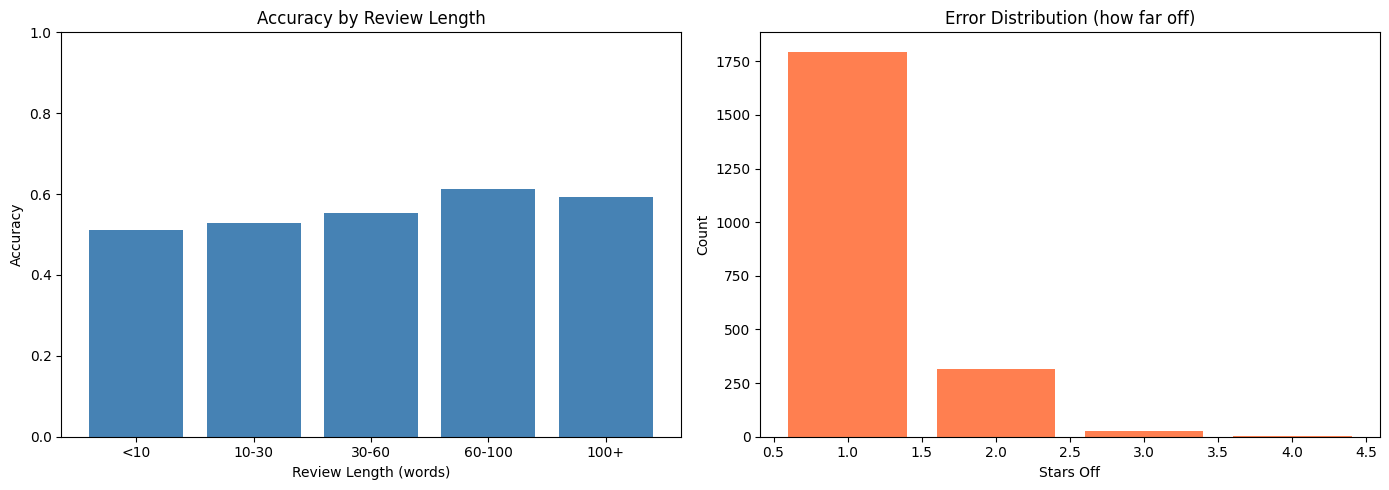


Accuracy by topic:
  Customer Service Quality: 0.638 (n=613)
  Overall Satisfaction & Value: 0.508 (n=742)
  Claims & Damage Handling: 0.511 (n=663)
  Communication & Responsiveness: 0.580 (n=1054)
  Ease & Speed of Service: 0.551 (n=1748)


In [ ]:
# Error analysis using best model predictions
best_model_name = comp_df.iloc[0]['Model']
print(f"Error analysis using: {best_model_name}\n")

# Use CamemBERT predictions if available, else LogReg
if 'CamemBERT' in best_model_name:
    y_pred_best = y_pred_cam
else:
    y_pred_best = lr_model.predict(X_val_tfidf)

errors = df_val.copy()
errors['predicted'] = y_pred_best
errors['correct'] = (y_pred_best == y_val)
errors['error'] = abs(y_pred_best - y_val)
err_mask = ~errors['correct']
print(f"Misclassified: {err_mask.sum()}/{len(df_val)} ({100*err_mask.mean():.1f}%)")

# Worst errors
worst = errors[errors['error'] >= 3].sort_values('error', ascending=False)
print(f"\n=== Worst Errors (off by ≥3 stars): {len(worst)} ===\n")
for _, row in worst.head(5).iterrows():
    text = str(row['avis_corrected'])[:200]
    print(f"  Actual: {row['label']}★  Predicted: {row['predicted']}★  Topic: {row['lda_topic_label']}")
    print(f"  '{text}...'\n")

# Accuracy by text length
errors['text_len'] = errors['avis_corrected'].fillna('').str.split().apply(len)
errors['len_bin'] = pd.cut(errors['text_len'], bins=[0, 10, 30, 60, 100, 2000],
                            labels=['<10', '10-30', '30-60', '60-100', '100+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
len_acc = errors.groupby('len_bin')['correct'].mean()
axes[0].bar(len_acc.index.astype(str), len_acc.values, color='steelblue')
axes[0].set_xlabel('Review Length (words)'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy by Review Length'); axes[0].set_ylim(0, 1)

err_dist = errors.loc[err_mask, 'error'].value_counts().sort_index()
axes[1].bar(err_dist.index, err_dist.values, color='coral')
axes[1].set_xlabel('Stars Off'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution (how far off)')
plt.tight_layout()
plt.show()

# Accuracy by topic
print("\nAccuracy by topic:")
for tid in sorted(df_val['lda_topic_id'].unique()):
    mask = df_val['lda_topic_id'] == tid
    acc = accuracy_score(y_val[mask], y_pred_best[mask])
    label = df_val.loc[mask, 'lda_topic_label'].iloc[0]
    print(f"  {label}: {acc:.3f} (n={mask.sum()})")

### Error Analysis — Interpretation

CamemBERT misclassifies 44.4% of reviews (2,139 / 4,820). The error patterns:

- **Most errors are off by 1 star** — adjacent ratings share vocabulary and tone. A "decent but overpriced" review could be 2★ or 3★ depending on the reviewer's personality.

- **Worst errors (off by ≥3 stars)**: these are cases where the text's surface sentiment contradicts the rating — e.g., a reviewer describes positive experiences in detail but gives 1★ because of a single critical issue at the end. The model reads the majority-positive text and predicts high stars.

- **Accuracy by topic** reveals structural difficulty:
  - *Customer Service Quality*: 0.638 — highest, because reviews here have clear sentiment
  - *Overall Satisfaction & Value*: 0.508 — lowest, because this broad topic mixes complaints and praise across diverse aspects
  - *Claims & Damage Handling*: 0.511 — nearly as hard, because claim outcomes create complex mixed-sentiment narratives

- **Short reviews** are harder (less signal), while longer reviews give the model more context to work with.

In [ ]:
# Save all metrics
for name in all_metrics:
    all_metrics[name]['training_time'] = round(training_times.get(name, 0), 1)
with open('data/05_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

# Save vocab
with open('data/05_vocab.json', 'w') as f:
    json.dump(word2idx, f)

# Verify all files
files = ['data/05_metrics.json', 'data/05_tfidf_logreg.joblib',
         'data/05_tfidf_vectorizer.joblib', 'data/05_trainable.pt',
         'data/05_w2v.pt', 'data/05_lstm.pt', 'data/05_cnn.pt',
         'data/05_camembert_model', 'data/05_vocab.json',
         'data/05_train_indices.npy', 'data/05_val_indices.npy']
print("Output files:")
for f_path in files:
    exists = os.path.exists(f_path)
    sz = ""
    if exists and os.path.isfile(f_path):
        sz = f" ({os.path.getsize(f_path)/1e6:.1f} MB)"
    elif exists:
        sz = " (dir)"
    print(f"  {'✓' if exists else '✗'} {f_path}{sz}")

Output files:
  ✓ data/05_metrics.json (0.0 MB)
  ✓ data/05_tfidf_logreg.joblib (1.2 MB)
  ✓ data/05_tfidf_vectorizer.joblib (1.2 MB)
  ✓ data/05_trainable.pt (6.0 MB)
  ✓ data/05_w2v.pt (6.0 MB)
  ✓ data/05_lstm.pt (6.7 MB)
  ✓ data/05_cnn.pt (6.4 MB)
  ✓ data/05_camembert_model (dir)
  ✓ data/05_vocab.json (0.3 MB)
  ✓ data/05_train_indices.npy (0.2 MB)
  ✓ data/05_val_indices.npy (0.0 MB)


In [ ]:
# Zip artifacts for download
import shutil
shutil.make_archive('/tmp/05_artifacts', 'zip', '.', 'data')
print("Artifacts zipped to /tmp/05_artifacts.zip")
print("Download manually from the Colab file browser if needed.")

Artifacts zipped to /tmp/05_artifacts.zip
Download manually from the Colab file browser if needed.


---
## Conclusions

| Family | Best Model | Macro-F1 | Key Takeaway |
|---|---|---|---|
| Classical ML | TF-IDF + LogReg | 0.465 | Strong baseline; trains in 7.5s |
| Neural (mean-pool) | W2V Embedding | 0.464 | Pre-training matches LogReg |
| Sequential | BiLSTM | 0.463 | Word order helps for extreme ratings |
| Convolutional | TextCNN | 0.453 | Best at detecting 2-star reviews |
| Transformer | CamemBERT | **0.491** | Best overall; 138 GB pre-training is decisive |
| Zero-shot | XLM-RoBERTa | 0.242 | No labels needed; 71% on 3-class sentiment |

**The fundamental challenge**: predicting exact star ratings from text tops out around 55% accuracy even with CamemBERT. The bottleneck is not the model but the data — different people assign different stars to reviews expressing similar sentiment. Collapsing to 3-class sentiment raises accuracy to 83%.

**For the Streamlit app**: TF-IDF + LogReg for fast CPU predictions (0.465 F1, 7.5s training), CamemBERT for best accuracy when GPU is available (0.491 F1).